In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('evaluation_results_23.csv')
df.head()

,patient_id,dsc,hd95,recall
0,BraTS-GLI-00137-000,0.5412,45.6924,0.5144
1,BraTS-GLI-01335-000,0.7560,44.6811,0.7646
2,BraTS-GLI-00823-000,0.2930,74.6425,0.2352
3,BraTS-GLI-01392-000,0.7887,17.4410,0.8003
4,BraTS-GLI-00235-000,0.6042,58.6668,0.5864


In [ ]:
metrics = df[['dsc', 'hd95', 'recall']]

summary_stats = metrics.describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats = summary_stats.rename(index={
    'mean': 'Mean',
    'std': 'Standard Deviation',
    'min': 'Minimum',
    '25%': '25th Percentile',
    '50%': 'Median',
    '75%': '75th Percentile',
    'max': 'Maximum'
})

summary_stats.T

,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,Maximum
dsc,0.400631,0.275361,0.0000,0.13045,0.4376,0.63940,0.9079
hd95,51.253134,24.226206,7.6158,34.03820,50.6946,66.97985,244.1397
recall,0.460949,0.331559,0.0000,0.11795,0.4940,0.74690,1.0000


In [10]:
df.shape

(1251, 4)

## Metrics 

- DSC - Above 0.8 is good.
- HD95 - Below 10 is good.
- Recall - Above 0.8 is good.

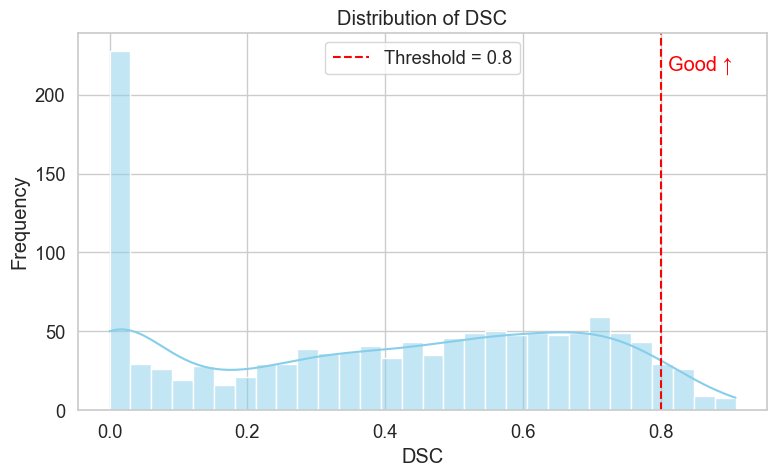

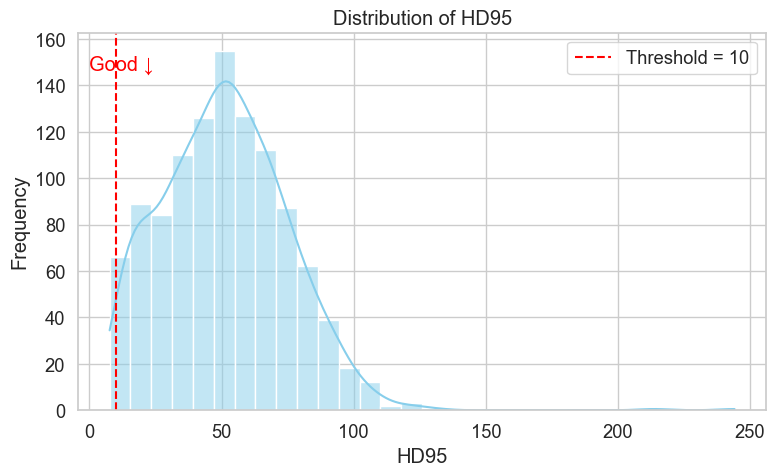

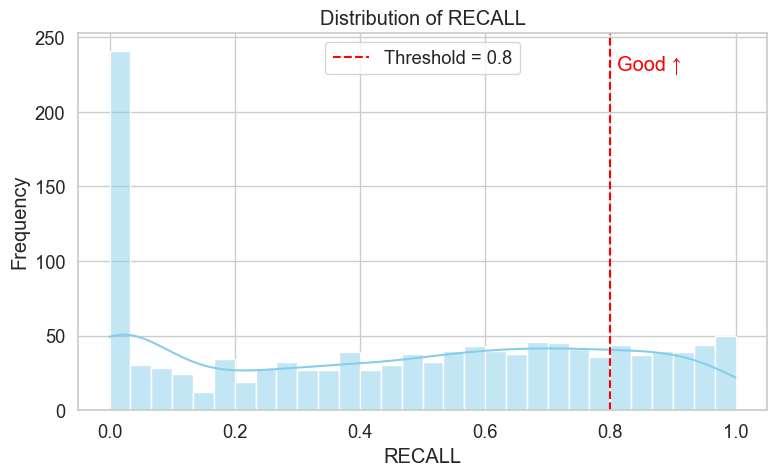

In [13]:
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

def plot_metric(metric, threshold, good_direction='above'):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[metric], bins=30, kde=True, color='skyblue')
    
    if good_direction == 'above':
        plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
        plt.text(threshold + 0.01, plt.ylim()[1]*0.9, 'Good ↑', color='red')
    else:
        plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
        plt.text(threshold - 10, plt.ylim()[1]*0.9, 'Good ↓', color='red')

    plt.title(f'Distribution of {metric.upper()}')
    plt.xlabel(metric.upper())
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric('dsc', threshold=0.8, good_direction='above')
plot_metric('hd95', threshold=10, good_direction='below')
plot_metric('recall', threshold=0.8, good_direction='above')

In [16]:
bad_rows = df[(df['dsc'] == 0) & (df['hd95'].isna()) & (df['recall'] == 0)]

count = len(bad_rows)

print(f"Total rows with dsc == 0, hd95 == NaN, recall == 0: {count}")

Total rows with dsc == 0, hd95 == NaN, recall == 0: 156
